<a href="https://colab.research.google.com/github/priscy-20/priscy-20/blob/main/Customer_Booking_Complete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

df = pd.read_csv('customer_booking.csv', encoding='latin1')
df.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


In [5]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
import chardet

with open('customer_booking.csv', 'rb') as rawdata:
    result = chardet.detect(rawdata.read(100000)) # Read first 100KB for detection

detected_encoding = result['encoding']
print(f"Detected encoding: {detected_encoding}")

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [8]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8566


In [9]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)
print("Cross-validation score:", scores.mean())

Cross-validation score: 0.7223599999999999


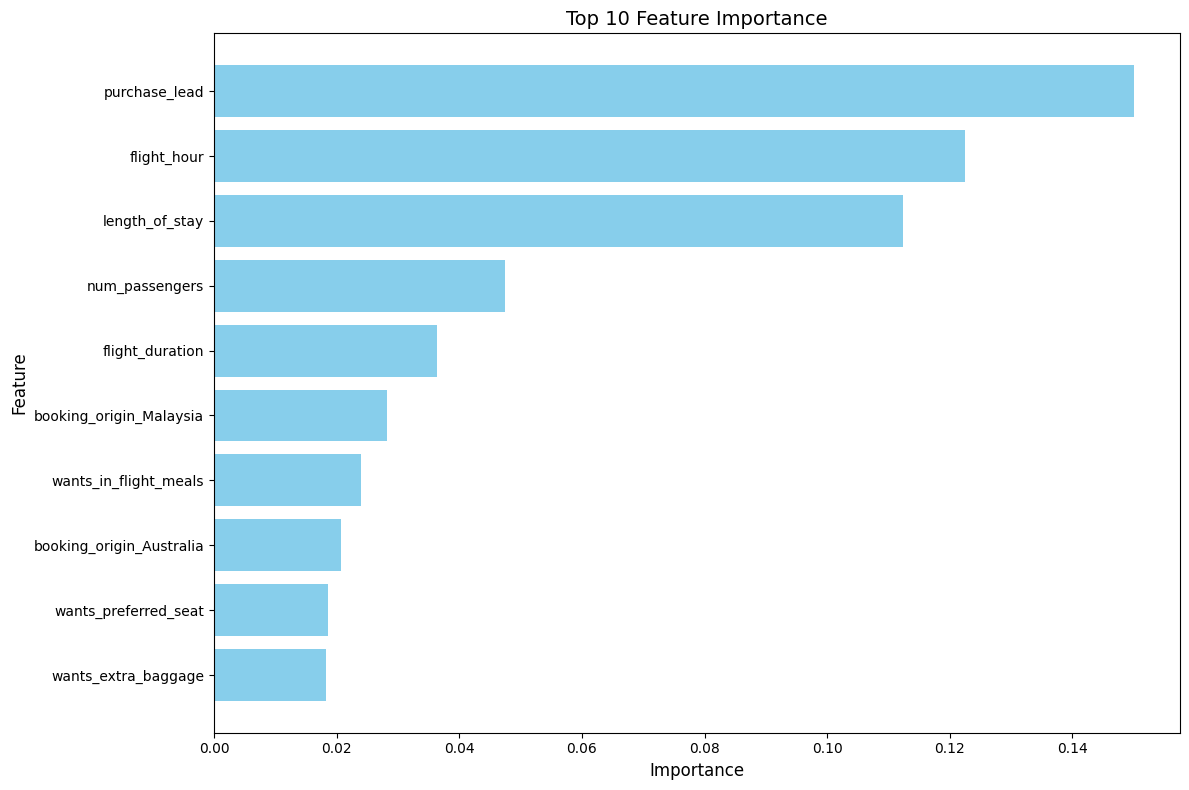

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

# Calculate feature importances and get feature names
importances = model.feature_importances_
features = X.columns

# Create a DataFrame to easily sort and display features and their importances
feature_importance_df = pd.DataFrame({'feature': features, 'importance': importances})

# Sort the DataFrame by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

# Select the top 10 features for better clarity
top_n_features = 10
top_features_df = feature_importance_df.head(top_n_features)

plt.figure(figsize=(12, 8)) # Increase figure size for better readability
plt.barh(top_features_df['feature'], top_features_df['importance'], color='skyblue')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title(f'Top {top_n_features} Feature Importance', fontsize=14)
plt.gca().invert_yaxis() # Display highest importance at the top
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

### Insights
- Top drivers of booking: purchase_lead, flight_hour, length_of_stay
- Customers who plan ahead and select add-ons are more likely to book
- Slight overfitting observed; model is strong but can be fine-tuned

In [ ]:
import pandas as pd

# Create a DataFrame to easily sort and display features and their importances
feature_importance_df = pd.DataFrame({'feature': features, 'importance': importances})

# Sort the DataFrame by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

# Display the top 5 features
display(feature_importance_df.head(5))

In [6]:
X = df.drop('booking_complete', axis=1)
y = df['booking_complete']

